# Hotel Room-Nights — PRODUCCIÓN (corrida semanal)

**Enjoy Costa Rica — Revenue Analytics**

Pronóstico operativo de room nights: portafolio activo, horizonte 365 días (12 meses).

**Campeón** (re-validación 2026-10-08, CHANGELOG 0.7.0): `Prophet(0.01, 10.0)` fijo
por propiedad + guard SeasonalNaive para <120 días de historia de ajuste +
congeladas excluidas por config. Sin lógica de selección en producción — la
selección es un experimento (ver gatillos abajo).

**Pisos honestos en cada corrida**: SeasonalNaive (semanal) y SN365 (año pasado ×
crecimiento YoY amortiguado). Si el campeón no los supera, el reporte lo dice.

**Gatillos de re-validación completa** (`hotel_roomnights_realdata.ipynb`, 9 modelos, ~45 min):
1. Cadencia trimestral/anual
2. Edge del campeón vs SN365 (test) < 5%
3. Propiedad nueva grande, cambio de composición, o cobertura conformal degradada 2 corridas seguidas

| Sección | Contenido |
|---|---|
| 1 | Carga + calidad (congeladas, frescura, cold-start) |
| 2 | Split honesto + campeón por propiedad + pisos + bottom-up |
| 3 | Cross-check top-down + bandas conformales (12 ventanas post-2024, MC fold-alineado) |
| 4 | Resumen operacional + estado de gatillos de re-validación |

In [1]:
import sys
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(name)s - %(levelname)s - %(message)s')

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

with open(PROJECT_ROOT / 'config.yaml') as f:
    CONFIG = yaml.safe_load(f)

RN = CONFIG['roomnights_real']
TARGET_COL = 'rooms_sold'
AVAIL_COL = 'available_rooms'
LEAD_BUCKETS = RN['lead_buckets']
MULTI_STEP_MIN_LEAD = RN['multi_step_min_lead']
HORIZON = RN['horizon_days']
TRAIN_YEARS = RN['training_window_years']
cold_min = RN['cold_start_min_history_days']
frozen_props = list(RN.get('frozen_properties') or [])
ALPHA = 0.2

CHAMPION = {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0}
MIN_FIT_DAYS = 120
STALE_DAYS = 7

print(f"Campeon: Prophet(cps={CHAMPION['changepoint_prior_scale']}, "
      f"sps={CHAMPION['seasonality_prior_scale']}) | Horizonte {HORIZON}d | "
      f"congeladas: {[RN['display_names'].get(p, p) for p in frozen_props]}")

Campeon: Prophet(cps=0.01, sps=10.0) | Horizonte 365d | congeladas: ['Lapas', 'LIRAK']


In [2]:
from src.forecasting.data.real_sources import load_real_aggregates
from src.forecasting.data.pickup import (
    build_pickup_features, portfolio_pickup, multi_step_pickup_columns,
)
from src.forecasting.data.aggregation import apply_capacity_ceiling, implied_occupancy
from src.forecasting.preprocessing import PreprocessingPipeline
from src.forecasting.models.statistical import ProphetForecaster
from src.forecasting.evaluation import Evaluator
from src.forecasting.evaluation.backtesting import make_rolling_folds, rolling_origin_backtest
from src.forecasting.evaluation.conformal import per_horizon_conformal_bands, empirical_coverage

print("Modulos importados")

Modulos importados


In [3]:
# --- Section 1: carga + calidad ---
paths = {k: PROJECT_ROOT / RN['csv_paths'][k] for k in ('demand', 'pickup', 'capacity')}
missing = [p for p in paths.values() if not p.exists()]
assert not missing, f"Exportaciones faltantes: {missing} — pedir a sistemas (README_SISTEMAS.md)"

quality_log = {}
AGG = load_real_aggregates(paths['demand'], paths['pickup'], paths['capacity'],
                          mapping_config=RN, exclusions_log=quality_log)
demand, pickup, capacity = AGG['demand'], AGG['pickup'], AGG['capacity']
display_name = RN['display_names']

prop_rows = []
for prop, g in demand.groupby('property'):
    days = g['stay_date'].nunique()
    cap_g = capacity[capacity['property'] == prop].set_index('business_date')['available_rooms']
    occ = (g.set_index('stay_date')['rooms_sold'] / cap_g.reindex(g['stay_date'])).mean()
    prop_rows.append({
        'property': display_name.get(prop, prop), 'key': prop, 'realized_days': days,
        'last_realized': g['stay_date'].max(),
        'fresh': g['stay_date'].max() >= demand['stay_date'].max() - pd.Timedelta(days=STALE_DAYS),
        'mean_rooms': g['rooms_sold'].mean(), 'mean_occupancy': occ,
        'cold_start': days < cold_min, 'frozen': prop in frozen_props,
    })
prop_report = pd.DataFrame(prop_rows).set_index('property')
display(prop_report.round(3))

if frozen_props:
    frozen_display = [display_name.get(k, k) for k in frozen_props]
    demand = demand[~demand['property'].isin(frozen_props)].reset_index(drop=True)
    pickup = pickup[~pickup['property'].isin(frozen_props)].reset_index(drop=True)
    capacity = capacity[~capacity['property'].isin(frozen_props)].reset_index(drop=True)
    print(f"CONGELADAS excluidas: {frozen_display}")
    print(f"Portafolio activo: {demand['property'].nunique()} propiedades | "
          f"{len(demand)} filas de demanda")

src.forecasting.data.real_sources - INFO - Real aggregates loaded: demand=13874 rows (8 properties), pickup=1565467 rows, capacity=39520 rows (6 fallback-filled days)


,key,realized_days,last_realized,fresh,mean_rooms,mean_occupancy,cold_start,frozen
property,,,,,,,,
Hotel Royal Corin,corin,1375,2026-10-06,True,39.582,0.529,False,False
Fiesta,fiesta,1010,2026-10-06,True,336.878,0.826,False,False
Lapas,lapas,936,2026-07-04,False,42.608,0.571,False,True
LIRAK,lirak,4087,2025-06-30,False,25.549,0.481,False,True
LIREL,lirel,3808,2026-10-06,True,64.635,0.628,False,False
Marina,marina,1375,2026-10-06,True,28.425,0.444,False,False
SJO (SJOSL),sjo,273,2026-10-06,True,28.216,0.393,False,False
Villas,villas,1010,2026-10-06,True,98.176,0.451,False,False


CONGELADAS excluidas: ['Lapas', 'LIRAK']
Portafolio activo: 6 propiedades | 8851 filas de demanda


In [4]:
# --- Section 2: frames + split honesto + helpers ---
port_demand = demand.groupby('stay_date')['rooms_sold'].sum().sort_index()
_full_idx = pd.date_range(port_demand.index.min(), port_demand.index.max(), freq='D')
port_demand = port_demand.reindex(_full_idx)
port_capacity = capacity.groupby('business_date')['available_rooms'].sum().sort_index()
port_capacity = port_capacity.reindex(_full_idx).ffill()

cutoff = port_demand.index.max() - pd.DateOffset(years=TRAIN_YEARS)
demand_recent = port_demand[port_demand.index > cutoff]
df_agg = pd.DataFrame({'date': demand_recent.index, TARGET_COL: demand_recent.values,
                       AVAIL_COL: port_capacity.reindex(demand_recent.index).values}
                      ).reset_index(drop=True)

port_pickup_feats = portfolio_pickup(pickup, LEAD_BUCKETS).set_index('stay_date')
rotb_cols_ml = multi_step_pickup_columns(LEAD_BUCKETS, MULTI_STEP_MIN_LEAD)

pipeline = PreprocessingPipeline(
    missing_strategy=CONFIG['preprocessing']['missing_values']['strategy'],
    outlier_method=CONFIG['preprocessing']['outliers']['method'],
    outlier_action=CONFIG['preprocessing']['outliers']['action'],
    feature_config={'lags': [1, 7, 14, 30, 365],
                    'rolling_windows': [7, 14, 30, 90],
                    'rolling_stats': ['mean', 'std', 'min', 'max'],
                    'expanding_stats': ['mean', 'std'],
                    'cyclical_features': ['dayofweek', 'dayofyear', 'month'],
                    'target_cols': [TARGET_COL]},
    split_config=CONFIG['preprocessing']['split'], scale_method=None, target_cols=[TARGET_COL],
)
split_result, _, _, test_feat = pipeline.run(df_agg, date_col='date')
test_df = test_feat[['date', TARGET_COL]].copy()
test_start = test_df['date'].min()
actuals_test = test_df[TARGET_COL].values
test_dates = pd.to_datetime(test_df['date'])
history_eval = df_agg[df_agg['date'] < test_start].reset_index(drop=True)
full_history = df_agg[['date', TARGET_COL]].copy()

future_dates = pd.date_range(full_history['date'].max() + pd.Timedelta(days=1),
                            periods=HORIZON, freq='D')
future_capacity_s = capacity.groupby('business_date')['available_rooms'].sum().sort_index()
last_obs = full_history['date'].max()
if last_obs in future_capacity_s.index:
    last_cap = float(future_capacity_s.loc[last_obs])
else:
    last_cap = float(future_capacity_s.iloc[-1])
future_capacity = pd.Series(np.full(HORIZON, last_cap))
folds12 = make_rolling_folds(test_start - pd.Timedelta(days=1), n_folds=12,
                             horizon_days=HORIZON, step_days=30)

print(f"Test: {test_start.date()} -> {test_df['date'].max().date()} ({len(test_df)}d) | "
      f"historia pre-test: {len(history_eval)}d | capacidad futura: {last_cap:.0f}")
print(f"Pisos honestos: SeasonalNaive(7d) y SN365 (año pasado x crecimiento amortiguado)")


def yoy_growth_s(hist_s, k=90, damp=0.5):
    if len(hist_s) < k + 200:
        return 1.0
    a1 = hist_s.iloc[-k:]
    a0 = hist_s.reindex(a1.index - pd.Timedelta(days=365)).dropna()
    a1v = a1.reindex(a0.index + pd.Timedelta(days=365))
    if len(a0) < 30 or a0.mean() <= 0:
        return 1.0
    return float(np.clip(a1v.mean() / a0.mean(), 0.6, 1.6) ** damp)


def profile4_series(hist_s, dates, weeks=4):
    tail = hist_s.iloc[-weeks * 7:]
    if len(tail) < 7:
        return np.full(len(dates), float(hist_s.mean()))
    prof = tail.groupby(tail.index.dayofweek).mean().reindex(range(7)).fillna(tail.mean())
    return prof.reindex(pd.DatetimeIndex(dates).dayofweek).values


def sn365_series(hist_s, dates):
    dts = pd.DatetimeIndex(dates)
    base = hist_s.reindex(dts - pd.Timedelta(days=365)).values.astype(float)
    preds = base * yoy_growth_s(hist_s)
    return np.where(np.isfinite(base), preds, profile4_series(hist_s, dates))


def sn7_preds(hist_vals, n):
    tail = np.asarray(hist_vals)[-7:]
    return np.array([tail[i % 7] for i in range(n)])


def prophet_pp(params, hist_s, dates):
    m = ProphetForecaster(**params)
    m.fit(pd.DataFrame({'date': pd.DatetimeIndex(hist_s.index), TARGET_COL: hist_s.values}),
          target_col=TARGET_COL, date_col='date')
    return m.predict(pd.DataFrame({'date': pd.DatetimeIndex(dates)}),
                     target_col=TARGET_COL, date_col='date').predictions


def prop_series(prop):
    g = demand[demand['property'] == prop].groupby('stay_date')['rooms_sold'].sum().sort_index()
    gi = pd.date_range(g.index.min(), g.index.max(), freq='D')
    return g.reindex(gi).ffill().bfill()

src.forecasting.data.pickup - INFO - Pickup features: 1751 (property, stay_date) rows x 7 buckets | coverage d7=99.6%, d365=79.1%


src.forecasting.preprocessing.splitter - INFO - Temporal split: train=1022, val=212, test=213 (gap=7 days)


src.forecasting.preprocessing.splitter - INFO - Split dates: train_end=2025-07-24, val_end=2026-02-28


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 44 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.preprocessing.splitter - INFO - Temporal split: train=1022, val=212, test=213 (gap=7 days)


src.forecasting.preprocessing.splitter - INFO - Split dates: train_end=2025-07-24, val_end=2026-02-28


src.forecasting.preprocessing.pipeline - INFO - Pipeline complete: train=1022 rows/50 cols, val=212, test=213


Test: 2026-03-08 -> 2026-10-06 (213d) | historia pre-test: 1248d | capacidad futura: 968
Pisos honestos: SeasonalNaive(7d) y SN365 (año pasado x crecimiento amortiguado)


In [5]:
# --- Section 2b: campeon por propiedad + pisos + bottom-up ---
evaluator = Evaluator()
global_last = demand['stay_date'].max()
median_completion = np.nan
completition = {}
warm_props = [p for p in demand['property'].unique()
              if demand[demand['property'] == p]['stay_date'].nunique() >= cold_min]
cold_props = [p for p in demand['property'].unique() if p not in warm_props]

for prop in warm_props:
    g = prop_series(prop)
    pick_g = build_pickup_features(
        pickup[pickup['property'] == prop], LEAD_BUCKETS).set_index('stay_date')
    h_df = pd.DataFrame({'date': g.index, TARGET_COL: g.values})
    h_df[rotb_cols_ml[0]] = pick_g[rotb_cols_ml[0]].reindex(h_df['date']).values
    recent = h_df.dropna(subset=[rotb_cols_ml[0]]).tail(120)
    if len(recent):
        completition[prop] = float((recent[TARGET_COL] / recent[rotb_cols_ml[0]]).median())
fresh_completion = [v for p, v in completition.items()
                    if demand[demand['property'] == p]['stay_date'].max()
                    >= global_last - pd.Timedelta(days=STALE_DAYS)]
if fresh_completion:
    median_completion = float(np.median(fresh_completion))


def books_estimate(pick_g, cap_future):
    books_future = pick_g[rotb_cols_ml[0]].reindex(future_dates).fillna(0.0).values
    est = books_future * (median_completion if np.isfinite(median_completion) else 1.0)
    if not np.isnan(cap_future):
        est = np.minimum(est, cap_future)
    return est


per_hotel_rows, per_hotel_future = [], []
bu_test_preds, sn7_test_preds, floor365_all, short_pools = {}, {}, {}, {}
stale_props_display = []
for prop in warm_props:
    g = prop_series(prop)
    fresh = g.index.max() >= global_last - pd.Timedelta(days=STALE_DAYS)
    status = 'fresh' if fresh else 'stale'
    if not fresh:
        stale_props_display.append(display_name.get(prop, prop))
    pre = g[g.index < test_start]
    h_test_dates = g.index[(g.index >= test_start) & (g.index <= test_df['date'].max())]
    pick_g = build_pickup_features(
        pickup[pickup['property'] == prop], LEAD_BUCKETS).set_index('stay_date')

    if len(pre) >= MIN_FIT_DAYS:
        method = 'Prophet(cps=0.01,sps=10.0)'
        preds_test = prophet_pp(CHAMPION, pre, h_test_dates)
    else:
        method = f'SeasonalNaive (guard <{MIN_FIT_DAYS}d)'
        preds_test = sn7_preds(pre.values, len(h_test_dates))
        if len(pre) > 7:
            short_pools[prop] = (pre.values[7:] - pre.values[:-7])[-60:]
        else:
            short_pools[prop] = np.zeros(1)
        print(f"GUARD {display_name.get(prop, prop)}: {len(pre)}d pre-test -> {method}")

    sn7p = sn7_preds(pre.values, len(h_test_dates))
    f365 = sn365_series(pre, h_test_dates) if len(pre) >= MIN_FIT_DAYS + 365 else None

    a_test = g.reindex(h_test_dates).values
    res_h = evaluator.compute_metrics(a_test, preds_test, model_name=prop)
    res_f = None
    if f365 is not None:
        res_f = evaluator.compute_metrics(a_test, f365, model_name=f'{prop}_sn365')

    bu_test_preds[prop] = pd.Series(preds_test, index=h_test_dates)
    sn7_test_preds[prop] = pd.Series(sn7p, index=h_test_dates)
    floor365_all[prop] = (pd.Series(f365, index=h_test_dates) if f365 is not None
                         else pd.Series(sn7p, index=h_test_dates))
    per_hotel_rows.append({
        'property': display_name.get(prop, prop), 'test_days': len(h_test_dates),
        'MAE': res_h.metrics['MAE'], 'WAPE': res_h.metrics['WAPE'],
        'Bias%': res_h.metrics['Bias%'],
        'sn365_MAE': res_f.metrics['MAE'] if res_f else np.nan,
        'sn365_Bias%': res_f.metrics['Bias%'] if res_f else np.nan,
        'method': method, 'status': status,
    })

    cap_g = (capacity[capacity['property'] == prop]
             .groupby('business_date')['available_rooms'].sum().sort_index())
    cap_future = float(cap_g.iloc[-1]) if len(cap_g) else np.nan
    if not fresh:
        preds_future = books_estimate(pick_g, cap_future)
        status_out = f'STALE (realizado hasta {g.index.max().date()}; estimado desde libros)'
    elif len(pre) >= MIN_FIT_DAYS:
        preds_future = prophet_pp(CHAMPION, g, future_dates)
        status_out = method
    else:
        preds_future = sn7_preds(g.values, HORIZON)
        status_out = method
    f_series = pd.Series(np.asarray(preds_future, dtype=float), index=future_dates)
    capped_h, _ = apply_capacity_ceiling(f_series, pd.Series(np.full(HORIZON, cap_future)))
    per_hotel_future.append(pd.DataFrame({'property': prop, 'date': future_dates,
                                          'forecast': capped_h.values,
                                          'capacity': cap_future, 'status': status_out}))

for prop in cold_props:
    pick_g = build_pickup_features(
        pickup[pickup['property'] == prop], LEAD_BUCKETS).set_index('stay_date')
    cap_g = (capacity[capacity['property'] == prop]
             .groupby('business_date')['available_rooms'].sum().sort_index())
    cap_future = float(cap_g.iloc[-1]) if len(cap_g) else np.nan
    per_hotel_future.append(pd.DataFrame({'property': prop, 'date': future_dates,
                                          'forecast': books_estimate(pick_g, cap_future),
                                          'capacity': cap_future,
                                          'status': 'COLD-START (libros x completitud)'}))
    print(f"COLD-START {display_name.get(prop, prop)}: estimado desde libros")

per_hotel_eval_df = pd.DataFrame(per_hotel_rows).set_index('property')
print("=== Campeon vs piso SN365 por propiedad (test en fechas propias) ===")
display(per_hotel_eval_df.round(2))

bu_frame = pd.concat(bu_test_preds, axis=1)
bu_test = bu_frame.sum(axis=1).reindex(test_dates).values
f365_frame = pd.concat(floor365_all, axis=1)
f365_test = f365_frame.sum(axis=1).reindex(test_dates).values
sn7_frame = pd.concat(sn7_test_preds, axis=1)
sn7_test = sn7_frame.sum(axis=1).reindex(test_dates).values
mask = test_dates.isin(bu_frame.dropna(axis=0).index)

bu_res = evaluator.compute_metrics(actuals_test[mask], bu_test[mask], model_name='ChampionBU')
f365_res = evaluator.compute_metrics(actuals_test[mask], f365_test[mask], model_name='SN365BU')
sn7_res = evaluator.compute_metrics(actuals_test[mask], sn7_test[mask], model_name='SNaiveBU')
print(f"\n=== PORTAFOLIO test ({int(mask.sum())}d): campeon vs pisos ===")
for nm, r in [('BOTTOM-UP campeon', bu_res), ('BOTTOM-UP SN365', f365_res),
             ('BOTTOM-UP SeasonalNaive', sn7_res)]:
    print(f"{nm:24s} MAE={r.metrics['MAE']:6.2f}  WAPE={r.metrics['WAPE']:5.2f}%  "
          f"Bias={r.metrics['Bias%']:+6.2f}%")
edge_vs_365 = (1 - bu_res.metrics['MAE'] / f365_res.metrics['MAE']) * 100
edge_vs_7 = (1 - bu_res.metrics['MAE'] / sn7_res.metrics['MAE']) * 100
print(f"\nEdge del campeon: {edge_vs_365:+.1f}% vs SN365 | {edge_vs_7:+.1f}% vs SNaive")
trigger = edge_vs_365 < 5
print(f"GATILLO re-validacion (edge < 5% vs SN365): {'SI -> correr re-validacion' if trigger else 'NO'}")

src.forecasting.data.pickup - INFO - Pickup features: 836 (property, stay_date) rows x 7 buckets | coverage d7=99.3%, d365=17.7%


src.forecasting.data.pickup - INFO - Pickup features: 1200 (property, stay_date) rows x 7 buckets | coverage d7=99.5%, d365=69.7%


src.forecasting.data.pickup - INFO - Pickup features: 1381 (property, stay_date) rows x 7 buckets | coverage d7=99.5%, d365=73.5%


src.forecasting.data.pickup - INFO - Pickup features: 1186 (property, stay_date) rows x 7 buckets | coverage d7=99.5%, d365=46.1%


src.forecasting.data.pickup - INFO - Pickup features: 511 (property, stay_date) rows x 7 buckets | coverage d7=100.0%, d365=1.2%


...

,test_days,MAE,WAPE,Bias%,sn365_MAE,sn365_Bias%,method,status
property,,,,,,,,
Hotel Royal Corin,213,7.74,23.56,1.06,7.43,-0.45,"Prophet(cps=0.01,sps=10.0)",fresh
Fiesta,213,37.21,11.01,-1.31,44.89,-1.60,"Prophet(cps=0.01,sps=10.0)",fresh
LIREL,213,21.46,25.26,12.51,19.01,-1.32,"Prophet(cps=0.01,sps=10.0)",fresh
Marina,213,4.89,17.27,-5.02,6.66,-7.63,"Prophet(cps=0.01,sps=10.0)",fresh
SJO (SJOSL),213,18.24,70.48,53.54,NaN,NaN,SeasonalNaive (guard <120d),fresh
Villas,213,24.96,30.36,26.55,23.67,12.03,"Prophet(cps=0.01,sps=10.0)",fresh


src.forecasting.evaluation.evaluator - INFO - ChampionBU (test): MAE=55.73, RMSE=70.59, MAPE=10.66%, WAPE=9.41%, Bias=+6.89% (152 over / 61 under)


src.forecasting.evaluation.evaluator - INFO - SN365BU (test): MAE=62.11, RMSE=81.73, MAPE=11.00%, WAPE=10.48%, Bias=+2.52% (130 over / 83 under)


src.forecasting.evaluation.evaluator - INFO - SNaiveBU (test): MAE=134.69, RMSE=154.76, MAPE=25.50%, WAPE=22.74%, Bias=+21.78% (194 over / 18 under)



=== PORTAFOLIO test (213d): campeon vs pisos ===
BOTTOM-UP campeon        MAE= 55.73  WAPE= 9.41%  Bias= +6.89%
BOTTOM-UP SN365          MAE= 62.11  WAPE=10.48%  Bias= +2.52%
BOTTOM-UP SeasonalNaive  MAE=134.69  WAPE=22.74%  Bias=+21.78%

Edge del campeon: +10.3% vs SN365 | +58.6% vs SNaive
GATILLO re-validacion (edge < 5% vs SN365): NO


cmdstanpy - DEBUG - cmd: where.exe tbb.dll
cwd: None


cmdstanpy - DEBUG - TBB already found in load path


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpucwhu7h6\kroe7x4l.json


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpucwhu7h6\e_s1u6fa.json


cmdstanpy - DEBUG - idx 0


...

15:59:06 - cmdstanpy - INFO - Chain [1] done processing


cmdstanpy - INFO - Chain [1] done processing


src.forecasting.models.statistical.prophet_model - INFO - Prophet fitted in 0.15 seconds on 432 rows.


src.forecasting.evaluation.backtesting - INFO - Backtest fold 11: window 2025-03-08 -> 2026-03-07 | history ends 2025-03-07 | 1 models


Banda bottom-up (MC fold-alineado, 3 folds representativos): cobertura test 71% vs nominal 80%
  Cobertura validada solo en los primeros 213d del horizonte; pasos 214-365 calibrados por folds (sin validacion en hold-out).


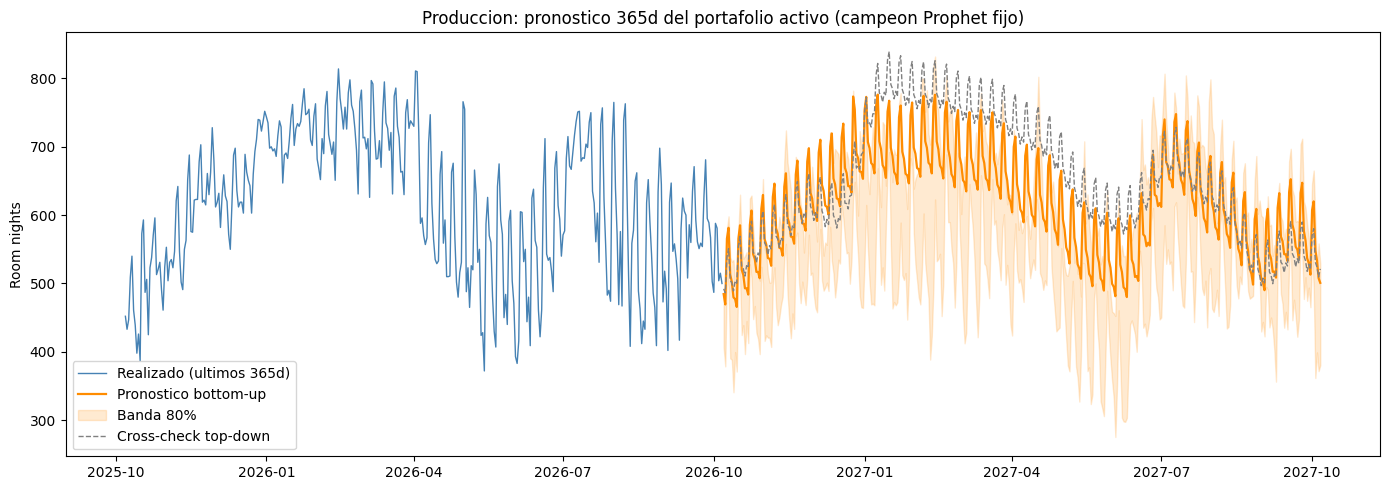

In [6]:
# --- Section 3: cross-check top-down + bandas conformales ---
td_hist_s = pd.Series(history_eval[TARGET_COL].values, index=pd.DatetimeIndex(history_eval['date']))
td_test = prophet_pp(CHAMPION, td_hist_s, test_dates)
td_res = evaluator.compute_metrics(actuals_test, td_test, model_name='TopDown')
gap_test = (bu_test.sum() / td_test.sum() - 1) * 100
print(f"TOP-DOWN campeon: MAE={td_res.metrics['MAE']:.2f} | WAPE={td_res.metrics['WAPE']:.2f}% | "
      f"Bias={td_res.metrics['Bias%']:+.2f}% | consistencia bottom-up: {gap_test:+.1f}%")
print("Bandas top-down de 365d RETIRADAS: todo fold del portafolio entrena a traves del "
      "cambio de composicion 2024 (150->660 rn/dia) y sobre-predice -100..-513/dia "
      "(medido 2026-10-08), sesgo que el modelo desplegado no comparte. El cross-check "
      "queda como punto + brecha.")

td_future = prophet_pp(CHAMPION, td_hist_s, future_dates)
td_future_capped, _ = apply_capacity_ceiling(pd.Series(td_future, index=future_dates),
                                             future_capacity)


def _champ_forecaster(hist, dates):
    s = pd.Series(hist[TARGET_COL].values, index=pd.DatetimeIndex(hist['date']))
    return prophet_pp(CHAMPION, s, dates)


# Bandas bottom-up: SOLO folds representativos — el entrenamiento del fold debe
# contener >=1 año completo de la composicion actual (ancla = ultima fecha de
# primer reporte entre las propiedades ajustadas + 1 año). Validado: 71% de
# cobertura en el overlap vs 55% con los 12 folds (D3 enmendada).
n_cov = min(HORIZON, len(actuals_test))
fitted_props = [p for p in bu_test_preds
                if len(prop_series(p)[prop_series(p).index < test_start]) >= MIN_FIT_DAYS]
join_dates = [demand[demand['property'] == p]['stay_date'].min() for p in fitted_props]
composition_floor = pd.Timestamp(max(join_dates)) + pd.DateOffset(years=1)
repr_idx = [i for i, f in enumerate(folds12) if f.window_start >= composition_floor]
if not repr_idx:
    repr_idx = list(range(max(0, len(folds12) - 3), len(folds12)))
    print(f"AVISO: sin folds con ancla de composicion ({composition_floor.date()}); "
          f"usando los {len(repr_idx)} mas recientes")
repr_folds = [folds12[i] for i in repr_idx]
print(f"Calibracion de bandas: {len(repr_idx)} folds representativos "
      f"(window_start >= {composition_floor.date()} = composicion actual + 1 año)")

res_sum = np.zeros((len(repr_idx), HORIZON))
for prop in fitted_props:
    g = prop_series(prop)
    usable_pos = [j for j, f in enumerate(repr_folds) if f.window_start > g.index.min()]
    if not usable_pos:
        continue
    usable = [repr_folds[j] for j in usable_pos]
    df_prop = pd.DataFrame({'date': g.index, TARGET_COL: g.values})
    bt_p = rolling_origin_backtest(df_prop, {'Champion': _champ_forecaster},
                                   usable, target_col=TARGET_COL)
    res_arr = np.asarray(bt_p.residuals['Champion'], dtype=float)
    r = np.full((len(repr_idx), HORIZON), np.nan)
    for k, j in enumerate(usable_pos):
        r[j] = res_arr[k]
    res_sum += np.nan_to_num(r, nan=0.0)

ph = pd.concat(per_hotel_future, ignore_index=True)
ph_daily = ph.groupby('date')['forecast'].sum()
bu_future = ph_daily.values
pool_all = np.concatenate([np.asarray(v) for v in short_pools.values()]) if short_pools else None
rng = np.random.default_rng(SEED)
lo_steps = np.zeros(HORIZON)
hi_steps = np.zeros(HORIZON)
for h in range(HORIZON):
    base = res_sum[:, h]
    if pool_all is not None:
        draws = base[:, None] + rng.choice(pool_all, size=(len(base), 500)).ravel()
    else:
        draws = base
    lo_steps[h] = np.quantile(draws, ALPHA / 2)
    hi_steps[h] = np.quantile(draws, 1 - ALPHA / 2)
bu_lo = np.maximum(bu_future + lo_steps, 0.0)
bu_hi = np.minimum(bu_future + hi_steps, future_capacity.values)
bu_test90 = bu_frame.sum(axis=1).reindex(test_dates).values[:n_cov]
cov_bu = empirical_coverage(actuals_test[:n_cov], bu_test90 + lo_steps[:n_cov],
                             bu_test90 + hi_steps[:n_cov])
print(f"Banda bottom-up (MC fold-alineado, {len(repr_idx)} folds representativos): "
      f"cobertura test {cov_bu:.0%} vs nominal {1-ALPHA:.0%}")
print(f"  Cobertura validada solo en los primeros {n_cov}d del horizonte; pasos "
      f"{n_cov + 1}-{HORIZON} calibrados por folds (sin validacion en hold-out).")

fig, ax = plt.subplots(figsize=(14, 5))
hist_view = port_demand.iloc[-365:]
ax.plot(hist_view.index, hist_view.values, label='Realizado (ultimos 365d)',
        color='steelblue', lw=1)
ax.plot(future_dates, bu_future, label='Pronostico bottom-up', color='darkorange', lw=1.6)
ax.fill_between(future_dates, bu_lo, bu_hi, alpha=0.18, color='darkorange', label='Banda 80%')
ax.plot(future_dates, td_future_capped.values, label='Cross-check top-down', color='gray',
        ls='--', lw=1)
ax.set_title(f'Produccion: pronostico {HORIZON}d del portafolio activo (campeon Prophet fijo)')
ax.set_ylabel('Room nights')
ax.legend()
fig.tight_layout()
plt.show()

In [7]:
# --- Section 4: resumen operacional + gatillos ---
books_total = float(port_pickup_feats[rotb_cols_ml[0]]
                    .reindex(future_dates).fillna(0).sum())
books_segments = []
for start, end, bucket in [(0, 90, 90), (90, 180, 180), (180, HORIZON, 365)]:
    if start >= HORIZON:
        break
    end = min(end, HORIZON)
    seg_dates = future_dates[start:end]
    b = float(port_pickup_feats[f'rotb_d{bucket}'].reindex(seg_dates).fillna(0).sum())
    fseg = float(bu_future[start:end].sum())
    books_segments.append((start + 1, end, bucket, b, fseg, (b / fseg if fseg else 0.0)))
bu_total = float(bu_future.sum())
future_occ = implied_occupancy(pd.Series(bu_future, index=future_dates), future_capacity)
n_guard = sum(1 for r in per_hotel_rows if 'guard' in r['method'])

print("=" * 70)
print("  PRODUCCION — ROOM NIGHTS 90d (portafolio activo, protocolo honesto)")
print("=" * 70)
print(f"\nTOTAL {HORIZON}d: {bu_total:,.0f} room nights | media {bu_future.mean():.1f}/dia | "
      f"ocupacion implícita: {future_occ.mean():.1%}")
print(f"Banda 80% (MC fold-alineado, {len(repr_idx)} folds representativos): "
      f"{bu_lo.sum():,.0f} – {bu_hi.sum():,.0f} | cobertura test ({n_cov}d de overlap): {cov_bu:.0%}")
print("Cobertura de libros por ventana (bucket as-of seguro):")
for s, e, bucket, b, fseg, pct in books_segments:
    print(f"  dias {s}-{e} (rotb_d{bucket}): {b:,.0f} de {fseg:,.0f} ({pct:.1%} ya en libros)")
print(f"Cross-check top-down: {float(td_future_capped.sum()):,.0f} "
      f"({(bu_total / float(td_future_capped.sum()) - 1) * 100:+.1f}%)")
print(f"\nVALIDACION test: bottom-up MAE {bu_res.metrics['MAE']:.2f} vs pisos: "
      f"SN365 {f365_res.metrics['MAE']:.2f} | SNaive {sn7_res.metrics['MAE']:.2f}")
print(f"Edge: {edge_vs_365:+.1f}% vs SN365 | GATILLO re-validacion: "
      f"{'SI' if trigger else 'NO'}")
print(f"\nPOR PROPIEDAD (metodo | MAE | sesgo | piso SN365 MAE):")
for r in per_hotel_rows:
    f365s = f"{r['sn365_MAE']:.1f}" if np.isfinite(r['sn365_MAE']) else 'n/d'
    print(f"  {r['property']:18s} {r['method']:28s} MAE={r['MAE']:6.2f} "
          f"Bias={r['Bias%']:+7.2f}%  SN365={f365s}")
print(f"\nFLAGS:")
if n_guard:
    print(f"  - Guard short-history activo en {n_guard} propiedad(es) — ver tabla")
if stale_props_display:
    print(f"  - STALE sin demanda reciente: {stale_props_display} -> estimado desde libros")
if frozen_props:
    print(f"  - CONGELADAS excluidas: {[display_name.get(p, p) for p in frozen_props]}")
print(f"  - Campeon fijo Prophet(0.01,10); re-validacion completa: "
      f"hotel_roomnights_realdata.ipynb (gatillos arriba)")
print(f"  - Datos: demanda {demand['stay_date'].min().date()} -> "
      f"{demand['stay_date'].max().date()}, {demand['property'].nunique()} propiedades activas")
print("=" * 70)

  PRODUCCION — ROOM NIGHTS 90d (portafolio activo, protocolo honesto)

TOTAL 365d: 225,602 room nights | media 618.1/dia | ocupacion implícita: 63.9%
Banda 80% (MC fold-alineado, 3 folds representativos): 180,677 – 234,295 | cobertura test (213d de overlap): 71%
Cobertura de libros por ventana (bucket as-of seguro):
  dias 1-90 (rotb_d90): 36,149 de 54,561 (66.3% ya en libros)
  dias 91-180 (rotb_d180): 19,342 de 62,071 (31.2% ya en libros)
  dias 181-365 (rotb_d365): 7,109 de 108,970 (6.5% ya en libros)
Cross-check top-down: 237,646 (-5.1%)

VALIDACION test: bottom-up MAE 55.73 vs pisos: SN365 62.11 | SNaive 134.69
Edge: +10.3% vs SN365 | GATILLO re-validacion: NO

POR PROPIEDAD (metodo | MAE | sesgo | piso SN365 MAE):
  Hotel Royal Corin  Prophet(cps=0.01,sps=10.0)   MAE=  7.74 Bias=  +1.06%  SN365=7.4
  Fiesta             Prophet(cps=0.01,sps=10.0)   MAE= 37.21 Bias=  -1.31%  SN365=44.9
  LIREL              Prophet(cps=0.01,sps=10.0)   MAE= 21.46 Bias= +12.51%  SN365=19.0
  Marina  